In [1]:
import itertools

import jax
import jax.numpy as jnp
import matplotlib.patches
import numpy as np
from matplotlib import pyplot as plt

from xxm.core.discrete.emissions import GaussianEmissions
from xxm.hmm.core import LatentInitialModel, LatentTransitionModel, Model
from xxm.hmm.inference import inference_exact
from xxm.hmm.init import initialize_hmm_gaussian
from xxm.hmm.learning import fit_em

In [2]:
def make_true_model() -> Model:
    return Model(
        initial=LatentInitialModel(
            initial_probs=jnp.array([0.4, 0.3, 0.3]),
        ),
        transitions=LatentTransitionModel(
            transition_probs=jnp.array(
                [
                    [0.90, 0.08, 0.02],
                    [0.05, 0.90, 0.05],
                    [0.03, 0.07, 0.90],
                ]
            )
        ),
        emissions=GaussianEmissions(
            means=jnp.array(
                [
                    [-3.0, -2.0],
                    [0.0, 3.0],
                    [3.0, -1.0],
                ]
            ),
            covariances=jnp.array(
                [
                    [[0.6, 0.2], [0.2, 0.5]],
                    [[0.8, -0.2], [-0.2, 0.5]],
                    [[0.5, 0.1], [0.1, 0.8]],
                ]
            ),
        ),
    )

In [3]:
true_model = make_true_model()

true_states, observations = true_model.sample(
    num_steps=1000,
    key=jax.random.key(0),
)

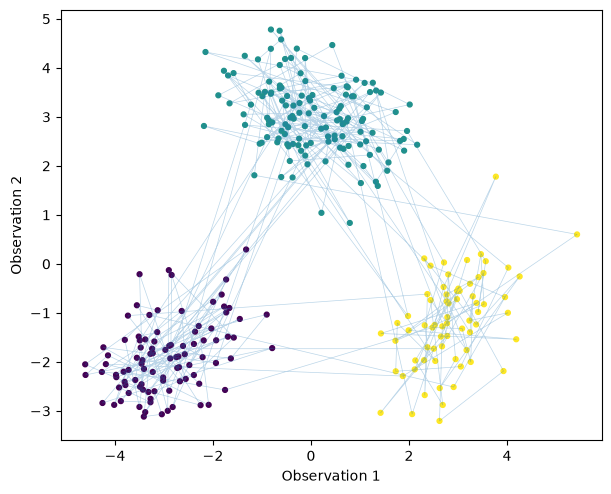

In [4]:
def plot_sequence(
    observations: jnp.ndarray,
    states: jnp.ndarray,
    num_steps: int = 300,
) -> None:
    observations = jnp.asarray(observations[:num_steps])
    states = jnp.asarray(states[:num_steps])

    f, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)

    ax.plot(
        observations[:, 0],
        observations[:, 1],
        linewidth=0.5,
        alpha=0.3,
    )

    ax.scatter(
        observations[:, 0],
        observations[:, 1],
        c=states,
        s=12,
    )

    ax.set_xlabel('Observation 1')
    ax.set_ylabel('Observation 2')
    ax.set_aspect('equal')


plot_sequence(observations, true_states)

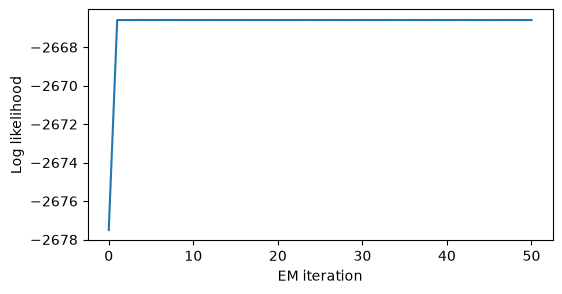

In [5]:
def plot_log_likelihood(log_likelihoods: jnp.ndarray) -> None:
    f, ax = plt.subplots(figsize=(6, 3))

    ax.plot(np.asarray(log_likelihoods))

    ax.set_xlabel('EM iteration')
    ax.set_ylabel('Log likelihood')


initial_model = initialize_hmm_gaussian(
    observations=observations,
    num_states=true_model.num_states,
    key=jax.random.key(0),
)


fit_em_jit = jax.jit(fit_em, static_argnames='num_iters')

learned_model, log_likelihoods = fit_em_jit(
    model=initial_model,
    observations=observations,
    num_iters=50,
)


plot_log_likelihood(log_likelihoods)

In [6]:
def match_states(
    true_means: jnp.ndarray,
    learned_means: jnp.ndarray,
) -> jax.Array:
    true_means = jnp.asarray(true_means)
    learned_means = jnp.asarray(learned_means)

    permutation = min(
        itertools.permutations(range(len(true_means))),
        key=lambda permutation: sum(
            jnp.linalg.norm(true_means[k] - learned_means[permutation[k]])
            for k in range(len(permutation))
        ),
    )

    return jnp.asarray(permutation)


permutation = match_states(
    true_model.emissions.means,
    learned_model.emissions.means,
)

matched_model = learned_model.permute(permutation)

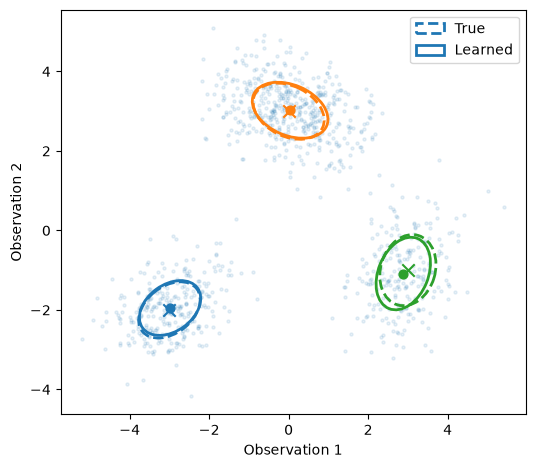

In [7]:
def add_covariance_ellipse(
    ax,
    mean: np.ndarray,
    covariance: np.ndarray,
    *,
    linestyle: str,
    label: str | None = None,
    **kwargs,
) -> None:
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)

    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    angle = np.degrees(
        np.arctan2(
            eigenvectors[1, 0],
            eigenvectors[0, 0],
        )
    )

    ellipse = matplotlib.patches.Ellipse(
        tuple(mean),
        width=2 * np.sqrt(eigenvalues[0]),
        height=2 * np.sqrt(eigenvalues[1]),
        angle=angle,
        fill=False,
        linestyle=linestyle,
        linewidth=2,
        label=label,
        **kwargs,
    )

    ax.add_patch(ellipse)


def plot_emissions(
    observations: jnp.ndarray,
    true_model: Model,
    learned_model: Model,
) -> None:
    f, ax = plt.subplots(figsize=(6, 6))

    ax.scatter(
        observations[:, 0],
        observations[:, 1],
        s=5,
        alpha=0.1,
    )

    for i in range(true_model.num_states):
        true_mean = np.asarray(true_model.emissions.means[i])

        add_covariance_ellipse(
            ax,
            true_mean,
            np.asarray(true_model.emissions.covariances[i]),
            linestyle='--',
            label='True' if i == 0 else None,
            color=f'C{i}',
        )

        ax.scatter(*true_mean, marker='x', s=80, color=f'C{i}')

    for i in range(learned_model.num_states):
        learned_mean = np.asarray(learned_model.emissions.means[i])

        add_covariance_ellipse(
            ax,
            learned_mean,
            np.asarray(learned_model.emissions.covariances[i]),
            linestyle='-',
            label='Learned' if i == 0 else None,
            color=f'C{i}',
        )
        ax.scatter(*learned_mean, marker='o', s=40, color=f'C{i}')

    ax.set_xlabel('Observation 1')
    ax.set_ylabel('Observation 2')
    ax.set_aspect('equal')
    ax.legend()


plot_emissions(
    observations,
    true_model,
    matched_model,
)

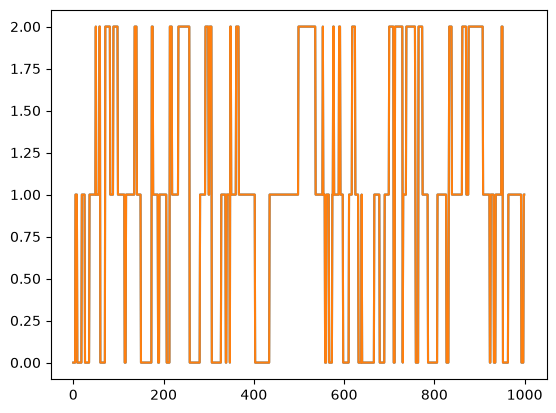

In [8]:
def plot_most_likely_states(matched_model, true_states, observations):

    posterior = inference_exact(matched_model, observations)

    f, ax = plt.subplots()

    ax.plot(true_states)
    ax.plot(np.argmax(posterior.state_marginals, axis=1))


plot_most_likely_states(matched_model, true_states, observations)